# Load libraries

In [19]:
import sys
from pathlib import Path
import pandas as pd
import time

# Move up one level to import
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import re
from collections import Counter

import av
from concurrent.futures import ThreadPoolExecutor

In [2]:
import torch
from torch.utils.data import DataLoader, Subset

from pytorchvideo.data.encoded_video import EncodedVideo

from src.x3d import X3D
from src.dataset import AUTSLDataset

objc[87802]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/videoCV/lib/python3.11/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x106bc43a8) and /opt/anaconda3/envs/videoCV/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1269f03a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[87802]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/videoCV/lib/python3.11/site-packages/av/.dylibs/libavdevice.62.3.102.dylib (0x106bc43f8) and /opt/anaconda3/envs/videoCV/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1269f03f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


# Dataset inspection

In [3]:
# Clips on disk in each split
counts = {}

for split in ("train", "val", "test"):
    counts[split] = len(list((ROOT / "data" / split).glob("*.mp4")))

    print(f"{split:5s} {counts[split]:>6,}")

print(f"{'total':5s} {sum(counts.values()):>6,}")

train 28,142
val    4,418
test   3,742
total 36,302


In [4]:
SPLIT_COLOURS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e8e7e3"


def style(panel, title):
    """
        Recessive chrome, shared by the inspection plots
    """
    panel.set_title(title, color = INK, fontsize = 11)
    panel.grid(axis = "y", color = GRID, linewidth = 0.8)
    panel.set_axisbelow(True)
    panel.margins(y = 0.15)
    panel.tick_params(colors = MUTED, labelsize = 9)

    for side in ("top", "right"):
        panel.spines[side].set_visible(False)

    for side in ("left", "bottom"):
        panel.spines[side].set_color(GRID)

In [5]:
SIGNER = re.compile(r"signer(\d+)_")

signers = {}

for split in ("train", "val", "test"):
    signers[split] = Counter(
        int(SIGNER.match(path.name).group(1))
        for path in (ROOT / "data" / split).glob("*.mp4")
    )


# Folder-agnostic: how many clips each signer contributed across every split
overall = Counter()

for counts in signers.values():
    overall.update(counts)

sizes = sorted(overall.values())

print(f"{len(overall)} signers, {sum(sizes):,} clips")
print(
    f"clips per signer   min {sizes[0]:,}   "
    f"median {sizes[len(sizes) // 2]:,}   "
    f"mean {sum(sizes) / len(sizes):,.0f}   "
    f"max {sizes[-1]:,}"
)


# Folder-wise: which signers appear where, and how many clips each contributed
for split, counts in signers.items():
    print(f"\n{split}: {len(counts)} signers, {sum(counts.values()):,} clips")

    entries = [f"signer{s:<3d}{counts[s]:>6,}" for s in sorted(counts)]

    for start in range(0, len(entries), 4):
        print("    " + "   ".join(entries[start:start + 4]))


# A signer in two splits would leak identity across them
print()

for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
    shared = sorted(set(signers[a]) & set(signers[b]))

    print(f"{a} & {b}: {shared if shared else 'no shared signers'}")

43 signers, 36,302 clips
clips per signer   min 436   median 662   mean 844   max 2,697

train: 31 signers, 28,142 clips
    signer0   1,350   signer2   1,356   signer3     672   signer4     672
    signer5     678   signer7   2,697   signer8   2,694   signer9     675
    signer10    669   signer12  2,026   signer13  2,022   signer15    448
    signer17    441   signer19    641   signer20    664   signer21    632
    signer22    627   signer23    678   signer24    669   signer26    645
    signer28    640   signer29    643   signer31    662   signer32    629
    signer33    660   signer36    654   signer37    650   signer38    641
    signer40    662   signer41    673   signer42    672

val: 6 signers, 4,418 clips
    signer1   1,344   signer11    669   signer16    436   signer18    663
    signer25    652   signer35    654

test: 6 signers, 3,742 clips
    signer6     678   signer14    441   signer27    639   signer30    662
    signer34    657   signer39    665

train & val: no share

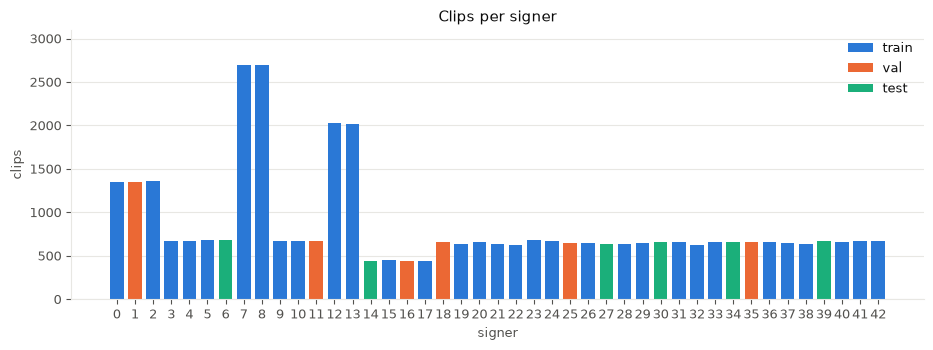

In [6]:
figure, panel = plt.subplots(figsize = (11, 3.5))

order = sorted(overall)

# The splits share no signers, so every bar takes the colour of its own split
for split, colour in SPLIT_COLOURS.items():
    members = [signer for signer in order if signer in signers[split]]

    panel.bar(
        members, [signers[split][signer] for signer in members],
        color = colour, width = 0.75, label = split,
    )

panel.set_xticks(order)
panel.set_xlabel("signer", color = MUTED, fontsize = 9)
panel.set_ylabel("clips", color = MUTED, fontsize = 9)
panel.tick_params(axis = "x", labelsize = 7)
panel.legend(frameon = False, fontsize = 9, labelcolor = INK)

style(panel, "Clips per signer")

In [7]:
# Class labels live in the CSVs, since the filenames do not carry them
classes = {}

for split in ("train", "val", "test"):
    with open(ROOT / "data" / f"{split}_labels.csv") as file:
        classes[split] = Counter(int(line.split(",")[1]) for line in file)


# Folder-agnostic: how many clips carry each label across every split
every_class = Counter()

for per_class in classes.values():
    every_class.update(per_class)


def describe(name, counter):
    spread = sorted(counter.values())

    print(
        f"{name}: {len(counter)} classes, {sum(spread):,} clips\n"
        f"    clips per class   min {spread[0]}   "
        f"median {spread[len(spread) // 2]}   "
        f"mean {sum(spread) / len(spread):.1f}   "
        f"max {spread[-1]}\n"
    )


describe("all splits", every_class)

# Folder-wise
for split, per_class in classes.items():
    describe(split, per_class)

# A class missing from a split could never be learned or scored there
absent = {
    split: sorted(set(every_class) - set(per_class))
    for split, per_class in classes.items()
}

print(f"classes absent from a split: {absent if any(absent.values()) else 'none'}")

all splits: 226 classes, 36,302 clips
    clips per class   min 121   median 162   mean 160.6   max 164

train: 226 classes, 28,142 clips
    clips per class   min 90   median 126   mean 124.5   max 127

val: 226 classes, 4,418 clips
    clips per class   min 12   median 20   mean 19.5   max 20

test: 226 classes, 3,742 clips
    clips per class   min 10   median 17   mean 16.6   max 17

classes absent from a split: none


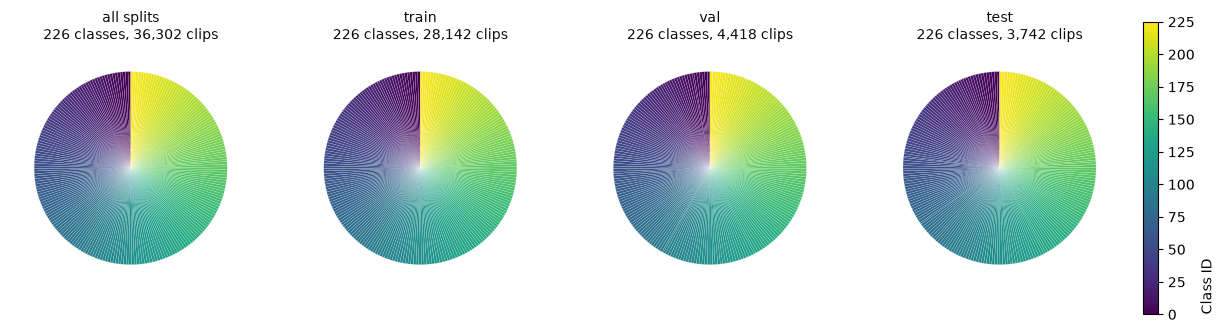

In [8]:
figure, axes = plt.subplots(1, 4, figsize = (15, 3.8))

panels = [("all splits", every_class)] + [
    (split, classes[split]) for split in ("train", "val", "test")
]

for panel, (title, counter) in zip(axes, panels):
    labels = sorted(counter)
    shares = [counter[label] for label in labels]

    # 226 wedges cannot be told apart individually, so the ramp runs with the
    # class id and the chart is read for its evenness, not slice by slice
    panel.pie(
        shares,
        colors = plt.cm.viridis([i / len(shares) for i in range(len(shares))]),
        wedgeprops = {"linewidth": 0.1, "edgecolor": "white"},
        startangle = 90,
    )

    panel.set_title(
        f"{title}\n{len(counter)} classes, {sum(shares):,} clips",
        color = INK, fontsize = 10,
    )

# Create colorbar using the same colormap and normalization
cmap = plt.cm.viridis
norm = plt.Normalize(vmin = 0, vmax = 225)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = figure.colorbar(
    sm,
    ax = axes,
    orientation = "vertical",
    fraction = 0.025,
    pad = 0.02,
)

cbar.set_label("Class ID", loc = "bottom")

# figure.tight_layout()

## Corrupt clips detection

During training the models, it returned some errors on some clips, thereby we suspected there may be other corrupt clips in the dataset. Therefore, we detect all of them herein, and the `dataset.py` shall skip a list of these clips during both training and testing phases.

In [9]:
# Truncated clips carry no moov atom, so PyAV cannot open them at all.
av.logging.set_level(av.logging.PANIC)


def readable(clip):
    try:
        with av.open(str(clip)) as container:
            return bool(container.streams.video)
    except av.error.FFmpegError:
        return False


for split in ("train", "val", "test"):
    clips = sorted((ROOT / "data" / split).glob("*.mp4"))

    with ThreadPoolExecutor(8) as pool:
        corrupt = [c.name for c, ok in zip(clips, pool.map(readable, clips)) if not ok]

    print(f"{split:5s} {len(corrupt):>3} unreadable of {len(clips):,}")

    for name in corrupt:
        print(f"      {name}")

train  10 unreadable of 28,142
      signer15_sample276_color.mp4
      signer20_sample424_color.mp4
      signer22_sample612_color.mp4
      signer2_sample1161_color.mp4
      signer36_sample356_color.mp4
      signer3_sample152_color.mp4
      signer41_sample25_color.mp4
      signer42_sample647_color.mp4
      signer5_sample618_color.mp4
      signer8_sample1406_color.mp4
val     0 unreadable of 4,418
test    1 unreadable of 3,742
      signer6_sample185_color.mp4


# Environment setup

In [10]:
device = "cpu"

MODEL_SIZE = "M"

# The variant carries its own clip geometry, so this is the only knob
NUM_FRAMES, CROP_SIZE = X3D.geometry(MODEL_SIZE)

# Training - Validation - Testing

These three partitioned sets are done in the python script rather than in this notebook.

# Inference on our custom dataset

For Mac user, since the custom Dataset only accepts `mp4`, while Mac saves the video as `mov`. We shall convert using the Terminal, navigate to the folder storing those videos, and run the following script:

```bash
for f in *.mov; do
    ffmpeg -i "$f" "${f%.mov}.mp4"
done
```

In [11]:
torch.manual_seed(42)

def build_split():
    dataset = AUTSLDataset(
        ROOT / "my_data" / "labels.csv",
        ROOT / "my_data",
        num_frames = NUM_FRAMES,
        crop_size = CROP_SIZE,
    )

    return dataset


test_loader = DataLoader(
    build_split(),
    batch_size = 1,
    shuffle = False,
    num_workers = 8,
    persistent_workers = True,
)

len(test_loader.dataset)

10

In [12]:
# # Kinetics-400 backbone, with a fresh head for the 226 AUTSL classes
clf = X3D(
    model_size = MODEL_SIZE,
    pretrained = True,
    num_classes = 226,
    device = device,
)

# Take the X3D_M with 2 frozen block as our final model
clf.load("../checkpoints/x3d_m_freeze2.pt")

## Prediction

In [ ]:
results = []

clf.model.eval()

for idx in range(len(test_loader.dataset)):
    video, label = test_loader.dataset[idx]

    start = time.perf_counter()
    with torch.no_grad():
        logits = clf.model(video[None, ...].to(device))
    inference_time = time.perf_counter() - start

    prob = torch.softmax(logits, dim=1)
    top5_probs, top5_ids = prob.topk(k=5, dim=1)

    results.append({
        "video_idx": idx,
        "true_class": label.item(),
        "top1": top5_ids[0, 0].item(),
        "top2": top5_ids[0, 1].item(),
        "top3": top5_ids[0, 2].item(),
        "top4": top5_ids[0, 3].item(),
        "top5": top5_ids[0, 4].item(),
        "top1_prob": top5_probs[0, 0].item(),
        "top2_prob": top5_probs[0, 1].item(),
        "top3_prob": top5_probs[0, 2].item(),
        "top4_prob": top5_probs[0, 3].item(),
        "top5_prob": top5_probs[0, 4].item(),
        "inference_time": inference_time
    })

df = pd.DataFrame(results).set_index("video_idx")

df.round(3)

,true_class,top1,top2,top3,top4,top5,top1_prob,top2_prob,top3_prob,top4_prob,top5_prob,inference_time
video_idx,,,,,,,,,,,,
0,161,161,11,194,155,158,1.000,0.000,0.000,0.000,0.000,0.326
1,77,77,173,64,0,151,0.667,0.283,0.038,0.013,0.000,0.325
2,22,18,173,204,220,0,0.974,0.013,0.006,0.006,0.001,0.302
3,157,213,1,54,204,172,0.860,0.140,0.000,0.000,0.000,0.308
4,112,32,8,64,77,112,0.680,0.319,0.000,0.000,0.000,0.341
5,128,54,166,201,155,13,0.703,0.180,0.116,0.001,0.000,0.307
6,14,14,199,211,164,126,1.000,0.000,0.000,0.000,0.000,0.302
7,5,5,102,192,149,172,1.000,0.000,0.000,0.000,0.000,0.293
8,23,23,85,102,173,169,0.987,0.011,0.001,0.000,0.000,0.372
